In [1]:
import os
from pathlib import Path

print(os.getcwd())

/Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/notebooks


In [2]:
PROJECT_DIR = Path("..")
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"

csv_files = sorted(RAW_DATA_DIR.rglob("*.csv"))

print("CSV files found:", len(csv_files))
for file in csv_files:
    print(file)

CSV files found: 8
../data/raw/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv


In [3]:
import pandas as pd
import numpy as np

dataframes = []

for file in csv_files:
    print(f"Loading: {file.name}")
    temp_df = pd.read_csv(file)
    temp_df["source_file"] = file.name
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined shape:", df.shape)
df.head()

Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-WorkingHours.pcap_ISCX.csv
Loading: Wednesday-workingHours.pcap_ISCX.csv
Combined shape: (2830743, 80)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,source_file
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv


In [4]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

label_col = " Label"

print("\nLabel counts:")
print(df[label_col].value_counts())


Number of rows: 2830743
Number of columns: 80

Columns:
[' Destination Port', ' Flow Duration', ' Total Fwd Packets', ' Total Backward Packets', 'Total Length of Fwd Packets', ' Total Length of Bwd Packets', ' Fwd Packet Length Max', ' Fwd Packet Length Min', ' Fwd Packet Length Mean', ' Fwd Packet Length Std', 'Bwd Packet Length Max', ' Bwd Packet Length Min', ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s', ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max', ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std', ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean', ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags', ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags', ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s', ' Bwd Packets/s', ' Min Packet Length', ' Max Packet Length', ' Packet Length Mean', ' Packet Length Std', ' Packet Length Variance', 'FIN Flag Count', ' SYN Flag Count', ' RST Flag C

In [5]:
# Clean column names by removing leading/trailing spaces
df.columns = df.columns.str.strip()

# Check cleaned columns
print(df.columns.tolist())

# Create binary target
df["binary_label"] = df["Label"].apply(lambda x: "BENIGN" if x == "BENIGN" else "ATTACK")

print("Binary label distribution:")
print(df["binary_label"].value_counts())

print("\nBinary label percentage:")
print(df["binary_label"].value_counts(normalize=True).mul(100).round(2))

['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count

In [6]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Missing values before cleaning:")
missing_summary = df.isna().sum()
print(missing_summary[missing_summary > 0].sort_values(ascending=False).head(20))

# Drop rows with missing values
original_shape = df.shape
df_clean = df.dropna().copy()

print("Original shape:", original_shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", original_shape[0] - df_clean.shape[0])

Missing values before cleaning:
Flow Bytes/s      2867
Flow Packets/s    2867
dtype: int64
Original shape: (2830743, 81)
Cleaned shape: (2827876, 81)
Rows removed: 2867


In [7]:
print("Final label counts:")
print(df_clean["Label"].value_counts())

print("\nFinal binary counts:")
print(df_clean["binary_label"].value_counts())

Final label counts:
Label
BENIGN                        2271320
DoS Hulk                       230124
PortScan                       158804
DDoS                           128025
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Final binary counts:
binary_label
BENIGN    2271320
ATTACK     556556
Name: count, dtype: int64


In [8]:
# Drop non-feature columns
drop_columns = ["Label", "binary_label", "source_file"]

X = df_clean.drop(columns=drop_columns)
y = df_clean["binary_label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (2827876, 78)
Target shape: (2827876,)

Target distribution:
binary_label
BENIGN    2271320
ATTACK     556556
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

In [12]:
RANDOM_STATE = 42

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training set: (2262300, 78)
Test set: (565576, 78)

Training distribution:
binary_label
BENIGN    80.32
ATTACK    19.68
Name: proportion, dtype: float64

Test distribution:
binary_label
BENIGN    80.32
ATTACK    19.68
Name: proportion, dtype: float64


In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support
)
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
import joblib

numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_features)
    ]
)

print("Number of numeric features:", len(numeric_features))

Number of numeric features: 78


In [15]:
def evaluate_model(model, X_data, y_true, dataset_name="Test"):
    y_pred = model.predict(X_data)

    accuracy = accuracy_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    attack_precision = precision_score(y_true, y_pred, pos_label="ATTACK", zero_division=0)
    attack_recall = recall_score(y_true, y_pred, pos_label="ATTACK", zero_division=0)
    attack_f1 = f1_score(y_true, y_pred, pos_label="ATTACK", zero_division=0)

    print(f"{dataset_name} Results")
    print("-" * 40)
    print(f"Accuracy:         {accuracy:.4f}")
    print(f"Macro Precision:  {macro_precision:.4f}")
    print(f"Macro Recall:     {macro_recall:.4f}")
    print(f"Macro F1-score:   {macro_f1:.4f}")
    print(f"Weighted F1:      {weighted_f1:.4f}")
    print(f"Attack Precision: {attack_precision:.4f}")
    print(f"Attack Recall:    {attack_recall:.4f}")
    print(f"Attack F1-score:  {attack_f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "dataset": dataset_name,
        "accuracy": accuracy,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "attack_precision": attack_precision,
        "attack_recall": attack_recall,
        "attack_f1": attack_f1
    }

In [16]:
dummy_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

dummy_model.fit(X_train, y_train)

dummy_results = evaluate_model(
    dummy_model,
    X_test,
    y_test,
    dataset_name="Test - Dummy Baseline"
)

Test - Dummy Baseline Results
----------------------------------------
Accuracy:         0.8032
Macro Precision:  0.4016
Macro Recall:     0.5000
Macro F1-score:   0.4454
Weighted F1:      0.7155
Attack Precision: 0.0000
Attack Recall:    0.0000
Attack F1-score:  0.0000

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.00      0.00      0.00    111311
      BENIGN       0.80      1.00      0.89    454265

    accuracy                           0.80    565576
   macro avg       0.40      0.50      0.45    565576
weighted avg       0.65      0.80      0.72    565576



In [17]:
dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

dt_model.fit(X_train, y_train)

dt_results = evaluate_model(
    dt_model,
    X_test,
    y_test,
    dataset_name="Test - Decision Tree"
)

Test - Decision Tree Results
----------------------------------------
Accuracy:         0.9989
Macro Precision:  0.9982
Macro Recall:     0.9983
Macro F1-score:   0.9982
Weighted F1:      0.9989
Attack Precision: 0.9970
Attack Recall:    0.9974
Attack F1-score:  0.9972

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    111311
      BENIGN       1.00      1.00      1.00    454265

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



In [18]:
et_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

et_model.fit(X_train, y_train)

et_results = evaluate_model(
    et_model,
    X_test,
    y_test,
    dataset_name="Test - Extra Trees"
)

Test - Extra Trees Results
----------------------------------------
Accuracy:         0.9988
Macro Precision:  0.9981
Macro Recall:     0.9980
Macro F1-score:   0.9981
Weighted F1:      0.9988
Attack Precision: 0.9969
Attack Recall:    0.9968
Attack F1-score:  0.9969

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    111311
      BENIGN       1.00      1.00      1.00    454265

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



In [19]:
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

log_reg_model.fit(X_train, y_train)

log_reg_results = evaluate_model(
    log_reg_model,
    X_test,
    y_test,
    dataset_name="Test - Logistic Regression"
)

Test - Logistic Regression Results
----------------------------------------
Accuracy:         0.9163
Macro Precision:  0.8515
Macro Recall:     0.9332
Macro F1-score:   0.8823
Weighted F1:      0.9207
Attack Precision: 0.7134
Attack Recall:    0.9610
Attack F1-score:  0.8189

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.71      0.96      0.82    111311
      BENIGN       0.99      0.91      0.95    454265

    accuracy                           0.92    565576
   macro avg       0.85      0.93      0.88    565576
weighted avg       0.94      0.92      0.92    565576



In [20]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    dataset_name="Test - Random Forest"
)

Test - Random Forest Results
----------------------------------------
Accuracy:         0.9990
Macro Precision:  0.9979
Macro Recall:     0.9990
Macro F1-score:   0.9985
Weighted F1:      0.9990
Attack Precision: 0.9960
Attack Recall:    0.9991
Attack F1-score:  0.9975

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    111311
      BENIGN       1.00      1.00      1.00    454265

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



In [21]:
pd.crosstab(df_clean["source_file"], df_clean["binary_label"])

binary_label,ATTACK,BENIGN
source_file,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,128025,97686
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,158804,127292
Friday-WorkingHours-Morning.pcap_ISCX.csv,1956,188955
Monday-WorkingHours.pcap_ISCX.csv,0,529481
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,36,288359
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,2180,168051
Tuesday-WorkingHours.pcap_ISCX.csv,13832,431813
Wednesday-workingHours.pcap_ISCX.csv,251723,439683


In [22]:
test_files = [
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"
]

train_day_df = df_clean[~df_clean["source_file"].isin(test_files)].copy()
test_day_df = df_clean[df_clean["source_file"].isin(test_files)].copy()

X_train_day = train_day_df.drop(columns=["Label", "binary_label", "source_file"])
y_train_day = train_day_df["binary_label"]

X_test_day = test_day_df.drop(columns=["Label", "binary_label", "source_file"])
y_test_day = test_day_df["binary_label"]

print("Train files:")
print(train_day_df["source_file"].value_counts())

print("\nTest files:")
print(test_day_df["source_file"].value_counts())

print("\nTrain label distribution:")
print(y_train_day.value_counts(normalize=True).mul(100).round(2))

print("\nTest label distribution:")
print(y_test_day.value_counts(normalize=True).mul(100).round(2))

Train files:
source_file
Wednesday-workingHours.pcap_ISCX.csv                           691406
Monday-WorkingHours.pcap_ISCX.csv                              529481
Tuesday-WorkingHours.pcap_ISCX.csv                             445645
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv    288395
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv         170231
Name: count, dtype: int64

Test files:
source_file
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    286096
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        225711
Friday-WorkingHours-Morning.pcap_ISCX.csv               190911
Name: count, dtype: int64

Train label distribution:
binary_label
BENIGN    87.4
ATTACK    12.6
Name: proportion, dtype: float64

Test label distribution:
binary_label
BENIGN    58.9
ATTACK    41.1
Name: proportion, dtype: float64


In [23]:
rf_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_day_model.fit(X_train_day, y_train_day)

rf_day_results = evaluate_model(
    rf_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - Random Forest"
)

Held-out Friday Files - Random Forest Results
----------------------------------------
Accuracy:         0.6688
Macro Precision:  0.8187
Macro Recall:     0.5971
Macro F1-score:   0.5530
Weighted F1:      0.5935
Attack Precision: 0.9972
Attack Recall:    0.1945
Attack F1-score:  0.3255

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.19      0.33    288785
      BENIGN       0.64      1.00      0.78    413933

    accuracy                           0.67    702718
   macro avg       0.82      0.60      0.55    702718
weighted avg       0.79      0.67      0.59    702718



In [24]:
rf_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_day_model.fit(X_train_day, y_train_day)

rf_day_results = evaluate_model(
    rf_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - Random Forest"
)

Held-out Friday Files - Random Forest Results
----------------------------------------
Accuracy:         0.6688
Macro Precision:  0.8187
Macro Recall:     0.5971
Macro F1-score:   0.5530
Weighted F1:      0.5935
Attack Precision: 0.9972
Attack Recall:    0.1945
Attack F1-score:  0.3255

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.19      0.33    288785
      BENIGN       0.64      1.00      0.78    413933

    accuracy                           0.67    702718
   macro avg       0.82      0.60      0.55    702718
weighted avg       0.79      0.67      0.59    702718



In [25]:
dt_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

dt_day_model.fit(X_train_day, y_train_day)

dt_day_results = evaluate_model(
    dt_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - Decision Tree"
)

Held-out Friday Files - Decision Tree Results
----------------------------------------
Accuracy:         0.6991
Macro Precision:  0.8122
Macro Recall:     0.6356
Macro F1-score:   0.6139
Weighted F1:      0.6462
Attack Precision: 0.9609
Attack Recall:    0.2791
Attack F1-score:  0.4326

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.96      0.28      0.43    288785
      BENIGN       0.66      0.99      0.80    413933

    accuracy                           0.70    702718
   macro avg       0.81      0.64      0.61    702718
weighted avg       0.79      0.70      0.65    702718



In [26]:
rf_day_probabilities = rf_day_model.predict_proba(X_test_day)

rf_day_probability_df = pd.DataFrame(
    rf_day_probabilities,
    columns=rf_day_model.classes_
)

rf_day_threshold_results = []

for threshold in np.arange(0.01, 0.51, 0.02):
    threshold_predictions = np.where(
        rf_day_probability_df["ATTACK"] >= threshold,
        "ATTACK",
        "BENIGN"
    )

    accuracy = accuracy_score(y_test_day, threshold_predictions)
    macro_f1 = f1_score(y_test_day, threshold_predictions, average="macro", zero_division=0)

    attack_precision, attack_recall, attack_f1, _ = precision_recall_fscore_support(
        y_test_day,
        threshold_predictions,
        labels=["ATTACK"],
        zero_division=0
    )

    rf_day_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "attack_precision": attack_precision[0],
        "attack_recall": attack_recall[0],
        "attack_f1": attack_f1[0]
    })

rf_day_threshold_results_df = pd.DataFrame(rf_day_threshold_results)
rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False)

,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
0,0.01,0.736146,0.702169,0.792694,0.484710,0.601574
1,0.03,0.710426,0.647889,0.862087,0.351611,0.499497
2,0.05,0.705007,0.633522,0.893381,0.320415,0.471665
3,0.07,0.698217,0.620765,0.898079,0.299662,0.449380
4,0.09,0.699471,0.618682,0.928822,0.291005,0.443165
7,0.15,0.704098,0.620289,0.982433,0.285060,0.441899
8,0.17,0.704298,0.620293,0.985528,0.284630,0.441695
9,0.19,0.704312,0.620151,0.987025,0.284222,0.441353
10,0.21,0.704445,0.620158,0.989048,0.283952,0.441229
15,0.31,0.705010,0.620417,0.995705,0.283405,0.441225


In [27]:
logreg_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logreg_day_model.fit(X_train_day, y_train_day)

logreg_day_results = evaluate_model(
    logreg_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - Logistic Regression"
)

Held-out Friday Files - Logistic Regression Results
----------------------------------------
Accuracy:         0.7543
Macro Precision:  0.8063
Macro Recall:     0.7091
Macro F1-score:   0.7128
Weighted F1:      0.7323
Attack Precision: 0.8956
Attack Recall:    0.4553
Attack F1-score:  0.6037

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.90      0.46      0.60    288785
      BENIGN       0.72      0.96      0.82    413933

    accuracy                           0.75    702718
   macro avg       0.81      0.71      0.71    702718
weighted avg       0.79      0.75      0.73    702718



In [28]:
logreg_day_probabilities = logreg_day_model.predict_proba(X_test_day)

logreg_day_probability_df = pd.DataFrame(
    logreg_day_probabilities,
    columns=logreg_day_model.classes_
)

logreg_day_threshold_results = []

for threshold in np.arange(0.01, 0.51, 0.02):
    threshold_predictions = np.where(
        logreg_day_probability_df["ATTACK"] >= threshold,
        "ATTACK",
        "BENIGN"
    )

    accuracy = accuracy_score(y_test_day, threshold_predictions)
    macro_f1 = f1_score(y_test_day, threshold_predictions, average="macro", zero_division=0)

    attack_precision, attack_recall, attack_f1, _ = precision_recall_fscore_support(
        y_test_day,
        threshold_predictions,
        labels=["ATTACK"],
        zero_division=0
    )

    logreg_day_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "attack_precision": attack_precision[0],
        "attack_recall": attack_recall[0],
        "attack_f1": attack_f1[0]
    })

logreg_day_threshold_results_df = pd.DataFrame(logreg_day_threshold_results)
logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False)

,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
21,0.43,0.754670,0.714071,0.890196,0.459730,0.606329
22,0.45,0.754792,0.713965,0.892310,0.458677,0.605901
23,0.47,0.754620,0.713420,0.894446,0.456810,0.604759
24,0.49,0.754337,0.712901,0.895162,0.455567,0.603832
15,0.31,0.747435,0.708768,0.852495,0.466060,0.602650
20,0.41,0.750211,0.710182,0.870663,0.460595,0.602473
16,0.33,0.747463,0.708553,0.854151,0.464865,0.602062
14,0.29,0.745261,0.707057,0.842698,0.467368,0.601268
17,0.35,0.747461,0.708224,0.856248,0.463255,0.601228
18,0.37,0.747539,0.708119,0.857694,0.462389,0.600854


In [29]:
et_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", ExtraTreesClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

et_day_model.fit(X_train_day, y_train_day)

et_day_results = evaluate_model(
    et_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - Extra Trees"
)

Held-out Friday Files - Extra Trees Results
----------------------------------------
Accuracy:         0.6196
Macro Precision:  0.8001
Macro Recall:     0.5372
Macro F1-score:   0.4475
Weighted F1:      0.5024
Attack Precision: 0.9925
Attack Recall:    0.0749
Attack F1-score:  0.1392

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.99      0.07      0.14    288785
      BENIGN       0.61      1.00      0.76    413933

    accuracy                           0.62    702718
   macro avg       0.80      0.54      0.45    702718
weighted avg       0.77      0.62      0.50    702718



In [30]:
et_day_probabilities = et_day_model.predict_proba(X_test_day)

et_day_probability_df = pd.DataFrame(
    et_day_probabilities,
    columns=et_day_model.classes_
)

et_day_threshold_results = []

for threshold in np.arange(0.01, 0.51, 0.02):
    threshold_predictions = np.where(
        et_day_probability_df["ATTACK"] >= threshold,
        "ATTACK",
        "BENIGN"
    )

    accuracy = accuracy_score(y_test_day, threshold_predictions)
    macro_f1 = f1_score(y_test_day, threshold_predictions, average="macro", zero_division=0)

    attack_precision, attack_recall, attack_f1, _ = precision_recall_fscore_support(
        y_test_day,
        threshold_predictions,
        labels=["ATTACK"],
        zero_division=0
    )

    et_day_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "attack_precision": attack_precision[0],
        "attack_recall": attack_recall[0],
        "attack_f1": attack_f1[0]
    })

et_day_threshold_results_df = pd.DataFrame(et_day_threshold_results)
et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False)

,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
0,0.01,0.721601,0.662987,0.885324,0.370552,0.522438
2,0.05,0.704533,0.620831,0.984409,0.285545,0.442682
3,0.07,0.704980,0.620883,0.990972,0.284703,0.442327
1,0.03,0.699648,0.617673,0.938889,0.287872,0.440639
4,0.09,0.704563,0.619874,0.993507,0.282944,0.440451
5,0.11,0.704200,0.619102,0.994742,0.281701,0.439063
6,0.13,0.703561,0.617878,0.995664,0.279876,0.436933
7,0.15,0.702919,0.616709,0.996020,0.278207,0.434930
8,0.17,0.701641,0.614419,0.996324,0.275000,0.431030
9,0.19,0.696864,0.605894,0.996397,0.263314,0.416548


In [31]:
hgb_day_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    ))
])

hgb_day_model.fit(X_train_day, y_train_day)

hgb_day_results = evaluate_model(
    hgb_day_model,
    X_test_day,
    y_test_day,
    dataset_name="Held-out Friday Files - HistGradientBoosting"
)

Held-out Friday Files - HistGradientBoosting Results
----------------------------------------
Accuracy:         0.6167
Macro Precision:  0.8000
Macro Recall:     0.5338
Macro F1-score:   0.4407
Weighted F1:      0.4966
Attack Precision: 0.9942
Attack Recall:    0.0678
Attack F1-score:  0.1269

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.99      0.07      0.13    288785
      BENIGN       0.61      1.00      0.75    413933

    accuracy                           0.62    702718
   macro avg       0.80      0.53      0.44    702718
weighted avg       0.77      0.62      0.50    702718



In [32]:
hgb_day_probabilities = hgb_day_model.predict_proba(X_test_day)

hgb_day_probability_df = pd.DataFrame(
    hgb_day_probabilities,
    columns=hgb_day_model.classes_
)

hgb_day_threshold_results = []

for threshold in np.arange(0.01, 0.51, 0.02):
    threshold_predictions = np.where(
        hgb_day_probability_df["ATTACK"] >= threshold,
        "ATTACK",
        "BENIGN"
    )

    accuracy = accuracy_score(y_test_day, threshold_predictions)
    macro_f1 = f1_score(y_test_day, threshold_predictions, average="macro", zero_division=0)

    attack_precision, attack_recall, attack_f1, _ = precision_recall_fscore_support(
        y_test_day,
        threshold_predictions,
        labels=["ATTACK"],
        zero_division=0
    )

    hgb_day_threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "attack_precision": attack_precision[0],
        "attack_recall": attack_recall[0],
        "attack_f1": attack_f1[0]
    })

hgb_day_threshold_results_df = pd.DataFrame(hgb_day_threshold_results)
hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False)

,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
0,0.01,0.708126,0.626757,0.987498,0.293481,0.452485
1,0.03,0.706382,0.623049,0.993571,0.287380,0.445813
2,0.05,0.706201,0.622567,0.995093,0.286493,0.444898
3,0.07,0.706132,0.622392,0.995603,0.286178,0.444569
4,0.09,0.706175,0.622404,0.996178,0.286116,0.444551
5,0.11,0.706154,0.622330,0.996513,0.285967,0.444404
6,0.13,0.705014,0.620322,0.996648,0.283145,0.441002
7,0.15,0.704785,0.619915,0.996702,0.282570,0.440310
8,0.17,0.704722,0.619785,0.996883,0.282366,0.440080
9,0.19,0.704654,0.619651,0.997014,0.282161,0.439844


In [33]:
heldout_best_results = pd.DataFrame([
    {
        "model": "Random Forest",
        "best_threshold": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "Logistic Regression",
        "best_threshold": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "Extra Trees",
        "best_threshold": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "HistGradientBoosting",
        "best_threshold": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    }
])

heldout_best_results = heldout_best_results.sort_values(by="attack_f1", ascending=False)
heldout_best_results.to_csv(RESULTS_DIR / "heldout_friday_best_threshold_results.csv", index=False)
heldout_best_results

NameError: name 'RESULTS_DIR' is not defined

In [34]:
from pathlib import Path

PROJECT_DIR = Path("..")
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [RESULTS_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

In [35]:
heldout_best_results = pd.DataFrame([
    {
        "model": "Random Forest",
        "best_threshold": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": rf_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "Logistic Regression",
        "best_threshold": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": logreg_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "Extra Trees",
        "best_threshold": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": et_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    },
    {
        "model": "HistGradientBoosting",
        "best_threshold": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["threshold"],
        "accuracy": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["accuracy"],
        "macro_f1": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["macro_f1"],
        "attack_precision": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_precision"],
        "attack_recall": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_recall"],
        "attack_f1": hgb_day_threshold_results_df.sort_values(by="attack_f1", ascending=False).iloc[0]["attack_f1"]
    }
])

heldout_best_results = heldout_best_results.sort_values(by="attack_f1", ascending=False)
heldout_best_results.to_csv(RESULTS_DIR / "heldout_friday_best_threshold_results.csv", index=False)
heldout_best_results

,model,best_threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
1,Logistic Regression,0.43,0.754670,0.714071,0.890196,0.459730,0.606329
0,Random Forest,0.01,0.736146,0.702169,0.792694,0.484710,0.601574
2,Extra Trees,0.01,0.721601,0.662987,0.885324,0.370552,0.522438
3,HistGradientBoosting,0.01,0.708126,0.626757,0.987498,0.293481,0.452485


In [36]:
heldout_best_results.to_csv(RESULTS_DIR / "heldout_friday_best_threshold_results.csv", index=False)
heldout_best_results

,model,best_threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
1,Logistic Regression,0.43,0.754670,0.714071,0.890196,0.459730,0.606329
0,Random Forest,0.01,0.736146,0.702169,0.792694,0.484710,0.601574
2,Extra Trees,0.01,0.721601,0.662987,0.885324,0.370552,0.522438
3,HistGradientBoosting,0.01,0.708126,0.626757,0.987498,0.293481,0.452485


In [37]:
model_results_df = pd.DataFrame([
    dummy_results,
    log_reg_results,
    dt_results,
    et_results,
    rf_results
])

model_results_df = model_results_df.sort_values(by="attack_f1", ascending=False)
model_results_df.to_csv(RESULTS_DIR / "random_split_model_comparison_results.csv", index=False)

model_results_df

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1
4,Test - Random Forest,0.999026,0.997880,0.999044,0.998461,0.999026,0.995988,0.999075,0.997529
2,Test - Decision Tree,0.998886,0.998168,0.998310,0.998239,0.998886,0.996983,0.997359,0.997171
3,Test - Extra Trees,0.998769,0.998067,0.998040,0.998054,0.998769,0.996909,0.996838,0.996874
1,Test - Logistic Regression,0.916349,0.851488,0.933194,0.882258,0.920676,0.713427,0.960974,0.818902
0,Test - Dummy Baseline,0.803190,0.401595,0.500000,0.445427,0.715525,0.000000,0.000000,0.000000


In [38]:
joblib.dump(rf_model, MODEL_DIR / "random_forest_random_split_model.joblib")
joblib.dump(logreg_day_model, MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

print("Saved Random Forest and Logistic Regression models.")

Saved Random Forest and Logistic Regression models.


In [39]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path("..")
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [RESULTS_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print("Results:", RESULTS_DIR.resolve())
print("Figures:", FIGURE_DIR.resolve())
print("Models:", MODEL_DIR.resolve())

Matplotlib is building the font cache; this may take a moment.


Folders ready:
Results: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/results
Figures: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/figures
Models: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/models


In [40]:
random_split_results = pd.DataFrame([
    dummy_results,
    log_reg_results,
    dt_results,
    et_results,
    rf_results
])

random_split_results = random_split_results.sort_values(by="attack_f1", ascending=False)
random_split_results.to_csv(RESULTS_DIR / "random_split_model_comparison_results.csv", index=False)

random_split_results

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1
4,Test - Random Forest,0.999026,0.997880,0.999044,0.998461,0.999026,0.995988,0.999075,0.997529
2,Test - Decision Tree,0.998886,0.998168,0.998310,0.998239,0.998886,0.996983,0.997359,0.997171
3,Test - Extra Trees,0.998769,0.998067,0.998040,0.998054,0.998769,0.996909,0.996838,0.996874
1,Test - Logistic Regression,0.916349,0.851488,0.933194,0.882258,0.920676,0.713427,0.960974,0.818902
0,Test - Dummy Baseline,0.803190,0.401595,0.500000,0.445427,0.715525,0.000000,0.000000,0.000000


In [41]:
heldout_best_results.to_csv(
    RESULTS_DIR / "heldout_friday_best_threshold_results.csv",
    index=False
)

heldout_best_results

,model,best_threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
1,Logistic Regression,0.43,0.754670,0.714071,0.890196,0.459730,0.606329
0,Random Forest,0.01,0.736146,0.702169,0.792694,0.484710,0.601574
2,Extra Trees,0.01,0.721601,0.662987,0.885324,0.370552,0.522438
3,HistGradientBoosting,0.01,0.708126,0.626757,0.987498,0.293481,0.452485


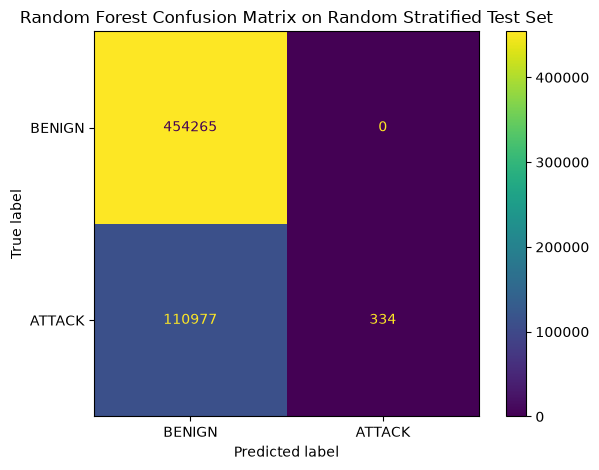

In [42]:
rf_random_predictions = rf_model.predict(X_test)

cm = confusion_matrix(
    y_test,
    rf_random_predictions,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix on Random Stratified Test Set")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "random_forest_random_split_confusion_matrix.png", dpi=300)
plt.show()

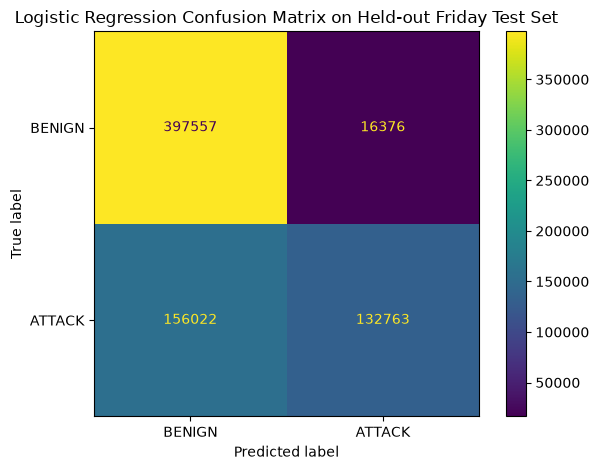

In [43]:
best_logreg_threshold = 0.43

logreg_day_probabilities = logreg_day_model.predict_proba(X_test_day)

logreg_day_probability_df = pd.DataFrame(
    logreg_day_probabilities,
    columns=logreg_day_model.classes_
)

logreg_heldout_predictions = np.where(
    logreg_day_probability_df["ATTACK"] >= best_logreg_threshold,
    "ATTACK",
    "BENIGN"
)

cm = confusion_matrix(
    y_test_day,
    logreg_heldout_predictions,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix on Held-out Friday Test Set")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "logistic_regression_heldout_friday_confusion_matrix.png", dpi=300)
plt.show()

In [44]:
joblib.dump(rf_model, MODEL_DIR / "random_forest_random_split_model.joblib")
joblib.dump(logreg_day_model, MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

print("Models saved:")
print(MODEL_DIR / "random_forest_random_split_model.joblib")
print(MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

Models saved:
../models/random_forest_random_split_model.joblib
../models/logistic_regression_heldout_friday_model.joblib


In [45]:
loaded_rf_model = joblib.load(MODEL_DIR / "random_forest_random_split_model.joblib")

loaded_rf_results = evaluate_model(
    loaded_rf_model,
    X_test,
    y_test,
    dataset_name="Loaded Random Forest - Random Split Test"
)

Loaded Random Forest - Random Split Test Results
----------------------------------------
Accuracy:         0.8038
Macro Precision:  0.9018
Macro Recall:     0.5015
Macro F1-score:   0.4486
Weighted F1:      0.7169
Attack Precision: 1.0000
Attack Recall:    0.0030
Attack F1-score:  0.0060

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.00      0.01    111311
      BENIGN       0.80      1.00      0.89    454265

    accuracy                           0.80    565576
   macro avg       0.90      0.50      0.45    565576
weighted avg       0.84      0.80      0.72    565576



In [46]:
loaded_logreg_model = joblib.load(MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

loaded_logreg_probabilities = loaded_logreg_model.predict_proba(X_test_day)

loaded_logreg_probability_df = pd.DataFrame(
    loaded_logreg_probabilities,
    columns=loaded_logreg_model.classes_
)

loaded_logreg_predictions = np.where(
    loaded_logreg_probability_df["ATTACK"] >= best_logreg_threshold,
    "ATTACK",
    "BENIGN"
)

print("Loaded Logistic Regression - Held-out Friday Test")
print("-" * 50)
print("Threshold:", best_logreg_threshold)
print("Accuracy:", accuracy_score(y_test_day, loaded_logreg_predictions))
print("Macro F1:", f1_score(y_test_day, loaded_logreg_predictions, average="macro", zero_division=0))
print("Attack Precision:", precision_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))
print("Attack Recall:", recall_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))
print("Attack F1:", f1_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test_day, loaded_logreg_predictions, zero_division=0))

Loaded Logistic Regression - Held-out Friday Test
--------------------------------------------------
Threshold: 0.43
Accuracy: 0.7546697252667499
Macro F1: 0.7140710074196626
Attack Precision: 0.8901963939680433
Attack Recall: 0.45972955659054315
Attack F1: 0.6063289520556078

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.89      0.46      0.61    288785
      BENIGN       0.72      0.96      0.82    413933

    accuracy                           0.75    702718
   macro avg       0.80      0.71      0.71    702718
weighted avg       0.79      0.75      0.73    702718



In [47]:
from pathlib import Path
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path("..")
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [RESULTS_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders ready:")
print("Results:", RESULTS_DIR.resolve())
print("Figures:", FIGURE_DIR.resolve())
print("Models:", MODEL_DIR.resolve())

Folders ready:
Results: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/results
Figures: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/figures
Models: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/models


In [48]:
random_split_results = pd.DataFrame([
    dummy_results,
    log_reg_results,
    dt_results,
    et_results,
    rf_results
])

random_split_results = random_split_results.sort_values(by="attack_f1", ascending=False)

random_split_results.to_csv(
    RESULTS_DIR / "random_split_model_comparison_results.csv",
    index=False
)

random_split_results

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1
4,Test - Random Forest,0.999026,0.997880,0.999044,0.998461,0.999026,0.995988,0.999075,0.997529
2,Test - Decision Tree,0.998886,0.998168,0.998310,0.998239,0.998886,0.996983,0.997359,0.997171
3,Test - Extra Trees,0.998769,0.998067,0.998040,0.998054,0.998769,0.996909,0.996838,0.996874
1,Test - Logistic Regression,0.916349,0.851488,0.933194,0.882258,0.920676,0.713427,0.960974,0.818902
0,Test - Dummy Baseline,0.803190,0.401595,0.500000,0.445427,0.715525,0.000000,0.000000,0.000000


In [49]:
heldout_best_results.to_csv(
    RESULTS_DIR / "heldout_friday_best_threshold_results.csv",
    index=False
)

heldout_best_results

,model,best_threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
1,Logistic Regression,0.43,0.754670,0.714071,0.890196,0.459730,0.606329
0,Random Forest,0.01,0.736146,0.702169,0.792694,0.484710,0.601574
2,Extra Trees,0.01,0.721601,0.662987,0.885324,0.370552,0.522438
3,HistGradientBoosting,0.01,0.708126,0.626757,0.987498,0.293481,0.452485


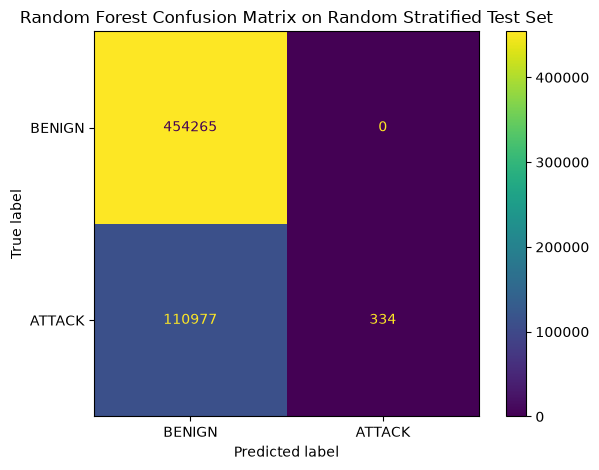

array([[454265,      0],
       [110977,    334]])

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_random_predictions = rf_model.predict(X_test)

cm_rf_random = confusion_matrix(
    y_test,
    rf_random_predictions,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_random,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Random Forest Confusion Matrix on Random Stratified Test Set")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "random_forest_random_split_confusion_matrix.png",
    dpi=300
)
plt.show()

cm_rf_random

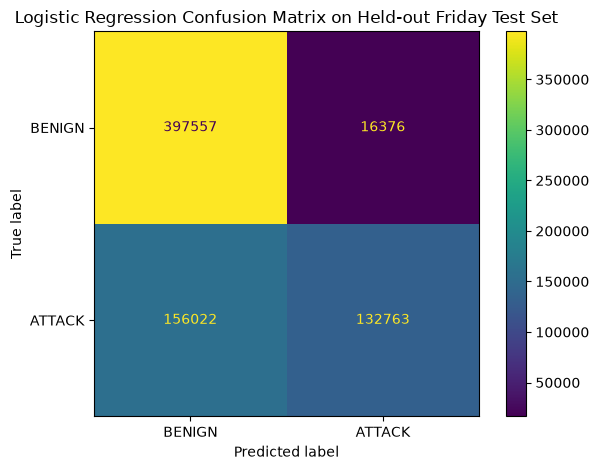

array([[397557,  16376],
       [156022, 132763]])

In [51]:
best_logreg_threshold = 0.43

logreg_day_probabilities = logreg_day_model.predict_proba(X_test_day)

logreg_day_probability_df = pd.DataFrame(
    logreg_day_probabilities,
    columns=logreg_day_model.classes_
)

logreg_heldout_predictions = np.where(
    logreg_day_probability_df["ATTACK"] >= best_logreg_threshold,
    "ATTACK",
    "BENIGN"
)

cm_logreg_heldout = confusion_matrix(
    y_test_day,
    logreg_heldout_predictions,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg_heldout,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix on Held-out Friday Test Set")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "logistic_regression_heldout_friday_confusion_matrix.png",
    dpi=300
)
plt.show()

cm_logreg_heldout

In [52]:
joblib.dump(
    rf_model,
    MODEL_DIR / "random_forest_random_split_model.joblib"
)

joblib.dump(
    logreg_day_model,
    MODEL_DIR / "logistic_regression_heldout_friday_model.joblib"
)

print("Models saved:")
print(MODEL_DIR / "random_forest_random_split_model.joblib")
print(MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

Models saved:
../models/random_forest_random_split_model.joblib
../models/logistic_regression_heldout_friday_model.joblib


In [53]:
loaded_rf_model = joblib.load(
    MODEL_DIR / "random_forest_random_split_model.joblib"
)

loaded_rf_results = evaluate_model(
    loaded_rf_model,
    X_test,
    y_test,
    dataset_name="Loaded Random Forest - Random Split Test"
)

Loaded Random Forest - Random Split Test Results
----------------------------------------
Accuracy:         0.8038
Macro Precision:  0.9018
Macro Recall:     0.5015
Macro F1-score:   0.4486
Weighted F1:      0.7169
Attack Precision: 1.0000
Attack Recall:    0.0030
Attack F1-score:  0.0060

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      0.00      0.01    111311
      BENIGN       0.80      1.00      0.89    454265

    accuracy                           0.80    565576
   macro avg       0.90      0.50      0.45    565576
weighted avg       0.84      0.80      0.72    565576



In [54]:
loaded_logreg_model = joblib.load(
    MODEL_DIR / "logistic_regression_heldout_friday_model.joblib"
)

loaded_logreg_probabilities = loaded_logreg_model.predict_proba(X_test_day)

loaded_logreg_probability_df = pd.DataFrame(
    loaded_logreg_probabilities,
    columns=loaded_logreg_model.classes_
)

loaded_logreg_predictions = np.where(
    loaded_logreg_probability_df["ATTACK"] >= best_logreg_threshold,
    "ATTACK",
    "BENIGN"
)

print("Loaded Logistic Regression - Held-out Friday Test")
print("-" * 50)
print("Threshold:", best_logreg_threshold)
print("Accuracy:", accuracy_score(y_test_day, loaded_logreg_predictions))
print("Macro F1:", f1_score(y_test_day, loaded_logreg_predictions, average="macro", zero_division=0))
print("Attack Precision:", precision_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))
print("Attack Recall:", recall_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))
print("Attack F1:", f1_score(y_test_day, loaded_logreg_predictions, pos_label="ATTACK", zero_division=0))

print("\nClassification Report:")
print(classification_report(y_test_day, loaded_logreg_predictions, zero_division=0))

Loaded Logistic Regression - Held-out Friday Test
--------------------------------------------------
Threshold: 0.43
Accuracy: 0.7546697252667499
Macro F1: 0.7140710074196626
Attack Precision: 0.8901963939680433
Attack Recall: 0.45972955659054315
Attack F1: 0.6063289520556078

Classification Report:
              precision    recall  f1-score   support

      ATTACK       0.89      0.46      0.61    288785
      BENIGN       0.72      0.96      0.82    413933

    accuracy                           0.75    702718
   macro avg       0.80      0.71      0.71    702718
weighted avg       0.79      0.75      0.73    702718



In [55]:
rf_classifier = rf_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_classifier.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.to_csv(
    RESULTS_DIR / "random_forest_feature_importance.csv",
    index=False
)

feature_importance_df.head(20)

,feature,importance
39,Max Packet Length,0.061157
0,Destination Port,0.059920
66,Init_Win_bytes_forward,0.054872
38,Min Packet Length,0.046420
11,Bwd Packet Length Min,0.041825
41,Packet Length Std,0.040995
52,Average Packet Size,0.039921
13,Bwd Packet Length Std,0.039139
67,Init_Win_bytes_backward,0.038396
42,Packet Length Variance,0.036590


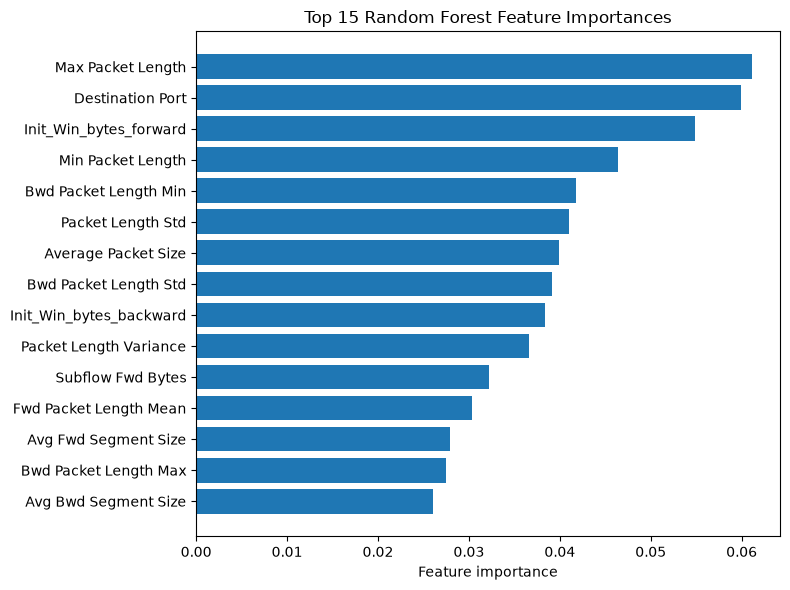

In [56]:
top_features = feature_importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "random_forest_top_feature_importance.png",
    dpi=300
)
plt.show()

In [57]:
file_label_crosstab = pd.crosstab(
    df_clean["source_file"],
    df_clean["binary_label"]
)

file_label_crosstab.to_csv(
    RESULTS_DIR / "source_file_binary_label_distribution.csv"
)

file_label_crosstab

binary_label,ATTACK,BENIGN
source_file,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,128025,97686
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv,158804,127292
Friday-WorkingHours-Morning.pcap_ISCX.csv,1956,188955
Monday-WorkingHours.pcap_ISCX.csv,0,529481
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv,36,288359
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv,2180,168051
Tuesday-WorkingHours.pcap_ISCX.csv,13832,431813
Wednesday-workingHours.pcap_ISCX.csv,251723,439683


In [58]:
attack_type_distribution = df_clean["Label"].value_counts().reset_index()
attack_type_distribution.columns = ["label", "count"]

attack_type_distribution.to_csv(
    RESULTS_DIR / "attack_type_distribution.csv",
    index=False
)

attack_type_distribution

,label,count
0,BENIGN,2271320
1,DoS Hulk,230124
2,PortScan,158804
3,DDoS,128025
4,DoS GoldenEye,10293
5,FTP-Patator,7935
6,SSH-Patator,5897
7,DoS slowloris,5796
8,DoS Slowhttptest,5499
9,Bot,1956


In [60]:
print("Result files:")
for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

print("\nFigure files:")
for file in sorted(FIGURE_DIR.iterdir()):
    print(file.name)

print("\nModel files:")
for file in sorted(MODEL_DIR.iterdir()):
    print(file.name)

Result files:
attack_type_distribution.csv
heldout_friday_best_threshold_results.csv
random_forest_feature_importance.csv
random_split_model_comparison_results.csv
source_file_binary_label_distribution.csv

Figure files:
logistic_regression_heldout_friday_confusion_matrix.png
random_forest_random_split_confusion_matrix.png
random_forest_top_feature_importance.png

Model files:
logistic_regression_heldout_friday_model.joblib
random_forest_random_split_model.joblib


In [61]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test,
    dataset_name="Test - Random Forest"
)

Test - Random Forest Results
----------------------------------------
Accuracy:         0.9990
Macro Precision:  0.9979
Macro Recall:     0.9990
Macro F1-score:   0.9985
Weighted F1:      0.9990
Attack Precision: 0.9960
Attack Recall:    0.9991
Attack F1-score:  0.9975

Classification Report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00    111311
      BENIGN       1.00      1.00      1.00    454265

    accuracy                           1.00    565576
   macro avg       1.00      1.00      1.00    565576
weighted avg       1.00      1.00      1.00    565576



In [62]:
# Final Leakage-Controlled Modelling Pipeline

In [63]:
# Final modelling dataset: remove exact duplicate records before splitting

feature_columns = [
    col for col in df_clean.columns
    if col not in ["Label", "binary_label", "source_file"]
]

dedup_subset = feature_columns + ["binary_label"]

original_rows = df_clean.shape[0]

df_model = df_clean.drop_duplicates(subset=dedup_subset).copy()

dedup_rows = df_model.shape[0]
removed_rows = original_rows - dedup_rows

print("Original cleaned rows:", original_rows)
print("Rows after deduplication:", dedup_rows)
print("Duplicate rows removed:", removed_rows)
print("Percentage removed:", round((removed_rows / original_rows) * 100, 3))

print("\nBinary distribution after deduplication:")
print(df_model["binary_label"].value_counts())
print(df_model["binary_label"].value_counts(normalize=True).mul(100).round(2))

Original cleaned rows: 2827876
Rows after deduplication: 2520798
Duplicate rows removed: 307078
Percentage removed: 10.859

Binary distribution after deduplication:
binary_label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [64]:
X = df_model[feature_columns]
y = df_model["binary_label"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

print("\nClass distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2))

Feature matrix: (2520798, 78)
Target: (2520798,)

Class distribution:
binary_label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [65]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# First split: 80% train+validation, 20% final test
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: from the 80%, create 64% train and 16% validation overall
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Training set:", X_train_final.shape)
print("Validation set:", X_val_final.shape)
print("Final test set:", X_test_final.shape)

print("\nTraining distribution:")
print(y_train_final.value_counts(normalize=True).mul(100).round(2))

print("\nValidation distribution:")
print(y_val_final.value_counts(normalize=True).mul(100).round(2))

print("\nFinal test distribution:")
print(y_test_final.value_counts(normalize=True).mul(100).round(2))

Training set: (1613310, 78)
Validation set: (403328, 78)
Final test set: (504160, 78)

Training distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64

Validation distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64

Final test distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [1]:
# Final modelling dataset: check and remove exact duplicate rows before splitting

feature_columns = [
    col for col in df_clean.columns
    if col not in ["Label", "binary_label", "source_file"]
]

dedup_subset = feature_columns + ["binary_label"]

original_rows = df_clean.shape[0]
duplicate_rows = df_clean.duplicated(subset=dedup_subset).sum()

df_model = df_clean.drop_duplicates(subset=dedup_subset).copy()

dedup_rows = df_model.shape[0]
removed_rows = original_rows - dedup_rows

print("Original cleaned rows:", original_rows)
print("Exact duplicate rows found:", duplicate_rows)
print("Rows after deduplication:", dedup_rows)
print("Duplicate rows removed:", removed_rows)
print("Percentage removed:", round((removed_rows / original_rows) * 100, 3))

print("\nBinary distribution after deduplication:")
print(df_model["binary_label"].value_counts())
print(df_model["binary_label"].value_counts(normalize=True).mul(100).round(2))

NameError: name 'df_clean' is not defined

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJECT_DIR = Path("..")
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

# find all CIC-IDS2017 csv files
csv_files = sorted(RAW_DATA_DIR.rglob("*.csv"))

print("CSV files found:", len(csv_files))
for file in csv_files:
    print(file)

# load and combine all files
dataframes = []

for file in csv_files:
    print("Loading:", file.name)
    temp_df = pd.read_csv(file, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip()
    temp_df["source_file"] = file.name
    dataframes.append(temp_df)

df = pd.concat(dataframes, ignore_index=True)

print("Combined shape:", df.shape)

# create binary label
df["binary_label"] = np.where(df["Label"] == "BENIGN", "BENIGN", "ATTACK")

# replace inf with NaN, then drop missing rows
df = df.replace([np.inf, -np.inf], np.nan)

missing_before = df.isna().sum()
missing_before = missing_before[missing_before > 0]

print("\nMissing values before cleaning:")
print(missing_before)

df_clean = df.dropna().copy()

print("\nOriginal shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

print("\nFinal label counts:")
print(df_clean["Label"].value_counts())

print("\nFinal binary counts:")
print(df_clean["binary_label"].value_counts())

CSV files found: 8
../data/raw/MachineLearningCVE/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Friday-WorkingHours-Morning.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Monday-WorkingHours.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Tuesday-WorkingHours.pcap_ISCX.csv
../data/raw/MachineLearningCVE/Wednesday-workingHours.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Loading: Monday-WorkingHours.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Loading: Tuesday-Work

In [3]:
# Final modelling dataset: check and remove exact duplicate rows before splitting

feature_columns = [
    col for col in df_clean.columns
    if col not in ["Label", "binary_label", "source_file"]
]

dedup_subset = feature_columns + ["binary_label"]

original_rows = df_clean.shape[0]
duplicate_rows = df_clean.duplicated(subset=dedup_subset).sum()

df_model = df_clean.drop_duplicates(subset=dedup_subset).copy()

dedup_rows = df_model.shape[0]
removed_rows = original_rows - dedup_rows

print("Original cleaned rows:", original_rows)
print("Exact duplicate rows found:", duplicate_rows)
print("Rows after deduplication:", dedup_rows)
print("Duplicate rows removed:", removed_rows)
print("Percentage removed:", round((removed_rows / original_rows) * 100, 3))

print("\nBinary distribution after deduplication:")
print(df_model["binary_label"].value_counts())
print(df_model["binary_label"].value_counts(normalize=True).mul(100).round(2))

Original cleaned rows: 2827876
Exact duplicate rows found: 307078
Rows after deduplication: 2520798
Duplicate rows removed: 307078
Percentage removed: 10.859

Binary distribution after deduplication:
binary_label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [4]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X = df_model[feature_columns]
y = df_model["binary_label"]

print("Feature matrix:", X.shape)
print("Target:", y.shape)

print("\nClass distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True).mul(100).round(2))

# First split: 80% train+validation, 20% final test
X_train_val, X_test_final, y_train_val, y_test_final = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Second split: from the 80%, create 64% train and 16% validation overall
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("\nTraining set:", X_train_final.shape)
print("Validation set:", X_val_final.shape)
print("Final test set:", X_test_final.shape)

print("\nTraining distribution:")
print(y_train_final.value_counts(normalize=True).mul(100).round(2))

print("\nValidation distribution:")
print(y_val_final.value_counts(normalize=True).mul(100).round(2))

print("\nFinal test distribution:")
print(y_test_final.value_counts(normalize=True).mul(100).round(2))

Feature matrix: (2520798, 78)
Target: (2520798,)

Class distribution:
binary_label
BENIGN    2095057
ATTACK     425741
Name: count, dtype: int64
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64

Training set: (1613310, 78)
Validation set: (403328, 78)
Final test set: (504160, 78)

Training distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64

Validation distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64

Final test distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    average_precision_score,
    roc_auc_score
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

PROJECT_DIR = Path("..")
RESULTS_DIR = PROJECT_DIR / "outputs" / "results"
FIGURE_DIR = PROJECT_DIR / "outputs" / "figures"
MODEL_DIR = PROJECT_DIR / "models"

for folder in [RESULTS_DIR, FIGURE_DIR, MODEL_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), feature_columns)
    ]
)

def get_attack_scores(model, X_data):
    attack_index = list(model.classes_).index("ATTACK")
    return model.predict_proba(X_data)[:, attack_index]

def evaluate_predictions(y_true, y_pred, y_score=None, dataset_name="Evaluation"):
    results = {
        "dataset": dataset_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "attack_precision": precision_score(y_true, y_pred, pos_label="ATTACK", zero_division=0),
        "attack_recall": recall_score(y_true, y_pred, pos_label="ATTACK", zero_division=0),
        "attack_f1": f1_score(y_true, y_pred, pos_label="ATTACK", zero_division=0)
    }

    if y_score is not None:
        y_binary = (y_true == "ATTACK").astype(int)
        results["pr_auc"] = average_precision_score(y_binary, y_score)
        results["roc_auc"] = roc_auc_score(y_binary, y_score)

    print(dataset_name)
    print("-" * 60)
    for key, value in results.items():
        if key != "dataset":
            print(f"{key}: {value:.4f}")

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return results

print("Setup complete.")
print("Results folder:", RESULTS_DIR.resolve())
print("Figures folder:", FIGURE_DIR.resolve())
print("Models folder:", MODEL_DIR.resolve())

Setup complete.
Results folder: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/results
Figures folder: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/outputs/figures
Models folder: /Users/tvishaprasad/Documents/AICS_CICIDS2017_Project/models


In [6]:
models = {
    "Dummy Baseline": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent"))
    ]),

    "Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Decision Tree": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Extra Trees": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", ExtraTreesClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            random_state=RANDOM_STATE
        ))
    ])
}

validation_results = []

for model_name, model in models.items():
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    model.fit(X_train_final, y_train_final)

    val_pred = model.predict(X_val_final)

    if hasattr(model.named_steps["classifier"], "predict_proba"):
        val_scores = get_attack_scores(model, X_val_final)
    else:
        val_scores = None

    result = evaluate_predictions(
        y_val_final,
        val_pred,
        y_score=val_scores,
        dataset_name=f"Validation - {model_name}"
    )

    result["model"] = model_name
    validation_results.append(result)

validation_results_df = pd.DataFrame(validation_results).sort_values(
    by="attack_f1",
    ascending=False
)

validation_results_df.to_csv(
    RESULTS_DIR / "validation_model_comparison_clean.csv",
    index=False
)

validation_results_df


Training Dummy Baseline
Validation - Dummy Baseline
------------------------------------------------------------
accuracy: 0.8311
macro_precision: 0.4156
macro_recall: 0.5000
macro_f1: 0.4539
weighted_f1: 0.7545
attack_precision: 0.0000
attack_recall: 0.0000
attack_f1: 0.0000
pr_auc: 0.1689
roc_auc: 0.5000

Classification report:
              precision    recall  f1-score   support

      ATTACK       0.00      0.00      0.00     68119
      BENIGN       0.83      1.00      0.91    335209

    accuracy                           0.83    403328
   macro avg       0.42      0.50      0.45    403328
weighted avg       0.69      0.83      0.75    403328


Training Logistic Regression
Validation - Logistic Regression
------------------------------------------------------------
accuracy: 0.9399
macro_precision: 0.8706
macro_recall: 0.9543
macro_f1: 0.9043
weighted_f1: 0.9430
attack_precision: 0.7463
attack_recall: 0.9760
attack_f1: 0.8458
pr_auc: 0.9465
roc_auc: 0.9876

Classification repor

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1,pr_auc,roc_auc,model
5,Validation - HistGradientBoosting,0.999107,0.998080,0.998744,0.998411,0.999108,0.996527,0.998194,0.997360,0.999252,0.999951,HistGradientBoosting
3,Validation - Random Forest,0.998887,0.997270,0.998775,0.998020,0.998888,0.994823,0.998605,0.996711,0.999808,0.999952,Random Forest
2,Validation - Decision Tree,0.998567,0.997494,0.997401,0.997447,0.998567,0.995874,0.995640,0.995757,0.992352,0.997409,Decision Tree
4,Validation - Extra Trees,0.998304,0.997199,0.996757,0.996978,0.998304,0.995532,0.994422,0.994977,0.995951,0.998609,Extra Trees
1,Validation - Logistic Regression,0.939917,0.870563,0.954280,0.904265,0.942953,0.746335,0.975969,0.845843,0.946511,0.987551,Logistic Regression
0,Validation - Dummy Baseline,0.831108,0.415554,0.500000,0.453882,0.754450,0.000000,0.000000,0.000000,0.168892,0.500000,Dummy Baseline


In [7]:
from sklearn.model_selection import train_test_split

# Stratified subset for efficient hyperparameter tuning.
# This subset is taken only from the training set, so the validation and final test sets remain untouched.

X_tune, _, y_tune, _ = train_test_split(
    X_train_final,
    y_train_final,
    train_size=250000,
    random_state=RANDOM_STATE,
    stratify=y_train_final
)

print("Tuning subset:", X_tune.shape)

print("\nTuning subset class counts:")
print(y_tune.value_counts())

print("\nTuning subset distribution:")
print(y_tune.value_counts(normalize=True).mul(100).round(2))

Tuning subset: (250000, 78)

Tuning subset class counts:
binary_label
BENIGN    207777
ATTACK     42223
Name: count, dtype: int64

Tuning subset distribution:
binary_label
BENIGN    83.11
ATTACK    16.89
Name: proportion, dtype: float64


In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

hgb_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

hgb_param_grid = {
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__max_iter": [100, 200],
    "classifier__max_leaf_nodes": [31, 63],
    "classifier__l2_regularization": [0.0, 0.1]
}

hgb_grid = GridSearchCV(
    estimator=hgb_tuning_pipeline,
    param_grid=hgb_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

hgb_grid.fit(X_tune, y_tune)

print("Best HistGradientBoosting parameters:")
print(hgb_grid.best_params_)

print("\nBest CV macro-F1:")
print(hgb_grid.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best HistGradientBoosting parameters:
{'classifier__l2_regularization': 0.1, 'classifier__learning_rate': 0.1, 'classifier__max_iter': 200, 'classifier__max_leaf_nodes': 31}

Best CV macro-F1:
0.998184263343905


In [9]:
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_param_grid = {
    "classifier__n_estimators": [100],
    "classifier__max_depth": [None, 40],
    "classifier__min_samples_split": [2, 5],
    "classifier__min_samples_leaf": [1]
}

rf_grid = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring="f1_macro",
    cv=cv,
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_tune, y_tune)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest CV macro-F1:")
print(rf_grid.best_score_)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
Best Random Forest parameters:
{'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Best CV macro-F1:
0.9975648555517704


In [10]:
# Train tuned models on the full training set and evaluate on validation set

best_hgb_model = hgb_grid.best_estimator_
best_rf_model = rf_grid.best_estimator_

print("Training tuned HistGradientBoosting on full training set...")
best_hgb_model.fit(X_train_final, y_train_final)

hgb_val_pred = best_hgb_model.predict(X_val_final)
hgb_val_scores = get_attack_scores(best_hgb_model, X_val_final)

tuned_hgb_val_results = evaluate_predictions(
    y_val_final,
    hgb_val_pred,
    y_score=hgb_val_scores,
    dataset_name="Validation - Tuned HistGradientBoosting"
)

print("\n" + "=" * 80)
print("Training tuned Random Forest on full training set...")
best_rf_model.fit(X_train_final, y_train_final)

rf_val_pred = best_rf_model.predict(X_val_final)
rf_val_scores = get_attack_scores(best_rf_model, X_val_final)

tuned_rf_val_results = evaluate_predictions(
    y_val_final,
    rf_val_pred,
    y_score=rf_val_scores,
    dataset_name="Validation - Tuned Random Forest"
)

tuned_validation_results_df = pd.DataFrame([
    {**tuned_hgb_val_results, "model": "Tuned HistGradientBoosting"},
    {**tuned_rf_val_results, "model": "Tuned Random Forest"}
]).sort_values(by="attack_f1", ascending=False)

tuned_validation_results_df.to_csv(
    RESULTS_DIR / "tuned_validation_results_clean.csv",
    index=False
)

tuned_validation_results_df

Training tuned HistGradientBoosting on full training set...
Validation - Tuned HistGradientBoosting
------------------------------------------------------------
accuracy: 0.9992
macro_precision: 0.9983
macro_recall: 0.9989
macro_f1: 0.9986
weighted_f1: 0.9992
attack_precision: 0.9969
attack_recall: 0.9984
attack_f1: 0.9977
pr_auc: 0.9999
roc_auc: 1.0000

Classification report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     68119
      BENIGN       1.00      1.00      1.00    335209

    accuracy                           1.00    403328
   macro avg       1.00      1.00      1.00    403328
weighted avg       1.00      1.00      1.00    403328


Training tuned Random Forest on full training set...
[CV] END classifier__l2_regularization=0.0, classifier__learning_rate=0.05, classifier__max_iter=200, classifier__max_leaf_nodes=31; total time=  55.7s
[CV] END classifier__l2_regularization=0.0, classifier__learning_rate=0.1, classifier__

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1,pr_auc,roc_auc,model
0,Validation - Tuned HistGradientBoosting,0.999217,0.998303,0.998909,0.998605,0.999217,0.996922,0.998444,0.997682,0.999888,0.999968,Tuned HistGradientBoosting
1,Validation - Tuned Random Forest,0.998867,0.997120,0.998856,0.997985,0.998868,0.994475,0.998840,0.996653,0.999804,0.999957,Tuned Random Forest


In [11]:
# Train tuned models on the full training set and evaluate on validation set

best_hgb_model = hgb_grid.best_estimator_
best_rf_model = rf_grid.best_estimator_

print("Training tuned HistGradientBoosting on full training set...")
best_hgb_model.fit(X_train_final, y_train_final)

hgb_val_pred = best_hgb_model.predict(X_val_final)
hgb_val_scores = get_attack_scores(best_hgb_model, X_val_final)

tuned_hgb_val_results = evaluate_predictions(
    y_val_final,
    hgb_val_pred,
    y_score=hgb_val_scores,
    dataset_name="Validation - Tuned HistGradientBoosting"
)

print("\n" + "=" * 80)
print("Training tuned Random Forest on full training set...")
best_rf_model.fit(X_train_final, y_train_final)

rf_val_pred = best_rf_model.predict(X_val_final)
rf_val_scores = get_attack_scores(best_rf_model, X_val_final)

tuned_rf_val_results = evaluate_predictions(
    y_val_final,
    rf_val_pred,
    y_score=rf_val_scores,
    dataset_name="Validation - Tuned Random Forest"
)

tuned_validation_results_df = pd.DataFrame([
    {**tuned_hgb_val_results, "model": "Tuned HistGradientBoosting"},
    {**tuned_rf_val_results, "model": "Tuned Random Forest"}
]).sort_values(by="attack_f1", ascending=False)

tuned_validation_results_df.to_csv(
    RESULTS_DIR / "tuned_validation_results_clean.csv",
    index=False
)

tuned_validation_results_df

Training tuned HistGradientBoosting on full training set...
Validation - Tuned HistGradientBoosting
------------------------------------------------------------
accuracy: 0.9992
macro_precision: 0.9983
macro_recall: 0.9989
macro_f1: 0.9986
weighted_f1: 0.9992
attack_precision: 0.9969
attack_recall: 0.9984
attack_f1: 0.9977
pr_auc: 0.9999
roc_auc: 1.0000

Classification report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     68119
      BENIGN       1.00      1.00      1.00    335209

    accuracy                           1.00    403328
   macro avg       1.00      1.00      1.00    403328
weighted avg       1.00      1.00      1.00    403328


Training tuned Random Forest on full training set...
Validation - Tuned Random Forest
------------------------------------------------------------
accuracy: 0.9989
macro_precision: 0.9971
macro_recall: 0.9989
macro_f1: 0.9980
weighted_f1: 0.9989
attack_precision: 0.9945
attack_recall: 0.9988

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1,pr_auc,roc_auc,model
0,Validation - Tuned HistGradientBoosting,0.999217,0.998303,0.998909,0.998605,0.999217,0.996922,0.998444,0.997682,0.999888,0.999968,Tuned HistGradientBoosting
1,Validation - Tuned Random Forest,0.998867,0.997120,0.998856,0.997985,0.998868,0.994475,0.998840,0.996653,0.999804,0.999957,Tuned Random Forest


In [12]:
def threshold_tuning(y_true, attack_scores, model_name, thresholds=np.arange(0.01, 0.91, 0.02)):
    rows = []

    for threshold in thresholds:
        preds = np.where(attack_scores >= threshold, "ATTACK", "BENIGN")

        rows.append({
            "model": model_name,
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, preds),
            "macro_f1": f1_score(y_true, preds, average="macro", zero_division=0),
            "attack_precision": precision_score(y_true, preds, pos_label="ATTACK", zero_division=0),
            "attack_recall": recall_score(y_true, preds, pos_label="ATTACK", zero_division=0),
            "attack_f1": f1_score(y_true, preds, pos_label="ATTACK", zero_division=0)
        })

    return pd.DataFrame(rows).sort_values(by="attack_f1", ascending=False)


hgb_threshold_results = threshold_tuning(
    y_val_final,
    hgb_val_scores,
    "Tuned HistGradientBoosting"
)

rf_threshold_results = threshold_tuning(
    y_val_final,
    rf_val_scores,
    "Tuned Random Forest"
)

threshold_results = pd.concat([
    hgb_threshold_results,
    rf_threshold_results
]).sort_values(by="attack_f1", ascending=False)

threshold_results.to_csv(
    RESULTS_DIR / "validation_threshold_tuning_clean.csv",
    index=False
)

threshold_results.head(20)

,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
23,Tuned HistGradientBoosting,0.47,0.999229,0.998628,0.996893,0.998547,0.997719
24,Tuned HistGradientBoosting,0.49,0.999224,0.998619,0.996907,0.998503,0.997704
21,Tuned HistGradientBoosting,0.43,0.999221,0.998615,0.996602,0.998796,0.997698
22,Tuned HistGradientBoosting,0.45,0.999221,0.998615,0.996674,0.998723,0.997698
29,Tuned HistGradientBoosting,0.59,0.999219,0.998610,0.997111,0.998268,0.997689
25,Tuned HistGradientBoosting,0.51,0.999217,0.998605,0.996922,0.998444,0.997682
28,Tuned HistGradientBoosting,0.57,0.999217,0.998605,0.997053,0.998312,0.997682
27,Tuned HistGradientBoosting,0.55,0.999212,0.998596,0.997024,0.998312,0.997667
26,Tuned HistGradientBoosting,0.53,0.999204,0.998583,0.996951,0.998341,0.997645
30,Tuned HistGradientBoosting,0.61,0.999199,0.998574,0.997155,0.998106,0.997630


In [13]:
best_hgb_threshold = hgb_threshold_results.iloc[0]["threshold"]
best_rf_threshold = rf_threshold_results.iloc[0]["threshold"]

print("Best HGB threshold:", best_hgb_threshold)
print("Best RF threshold:", best_rf_threshold)

print("\nBest HGB validation threshold row:")
display(hgb_threshold_results.head(1))

print("\nBest RF validation threshold row:")
display(rf_threshold_results.head(1))

Best HGB threshold: 0.4699999999999999
Best RF threshold: 0.6099999999999999

Best HGB validation threshold row:


,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
23,Tuned HistGradientBoosting,0.47,0.999229,0.998628,0.996893,0.998547,0.997719



Best RF validation threshold row:


,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
30,Tuned Random Forest,0.61,0.998909,0.998059,0.995751,0.997798,0.996774


In [14]:
# Final untouched test evaluation using thresholds selected on validation set only

hgb_test_scores = get_attack_scores(best_hgb_model, X_test_final)
hgb_test_preds = np.where(
    hgb_test_scores >= best_hgb_threshold,
    "ATTACK",
    "BENIGN"
)

final_hgb_test_results = evaluate_predictions(
    y_test_final,
    hgb_test_preds,
    y_score=hgb_test_scores,
    dataset_name="Final Test - Tuned HistGradientBoosting"
)

final_hgb_test_results["model"] = "Tuned HistGradientBoosting"
final_hgb_test_results["threshold"] = best_hgb_threshold


rf_test_scores = get_attack_scores(best_rf_model, X_test_final)
rf_test_preds = np.where(
    rf_test_scores >= best_rf_threshold,
    "ATTACK",
    "BENIGN"
)

final_rf_test_results = evaluate_predictions(
    y_test_final,
    rf_test_preds,
    y_score=rf_test_scores,
    dataset_name="Final Test - Tuned Random Forest"
)

final_rf_test_results["model"] = "Tuned Random Forest"
final_rf_test_results["threshold"] = best_rf_threshold


final_test_results_clean = pd.DataFrame([
    final_hgb_test_results,
    final_rf_test_results
]).sort_values(by="attack_f1", ascending=False)

final_test_results_clean.to_csv(
    RESULTS_DIR / "final_test_results_clean.csv",
    index=False
)

final_test_results_clean

Final Test - Tuned HistGradientBoosting
------------------------------------------------------------
accuracy: 0.9992
macro_precision: 0.9981
macro_recall: 0.9988
macro_f1: 0.9985
weighted_f1: 0.9992
attack_precision: 0.9966
attack_recall: 0.9984
attack_f1: 0.9975
pr_auc: 0.9999
roc_auc: 1.0000

Classification report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

Final Test - Tuned Random Forest
------------------------------------------------------------
accuracy: 0.9989
macro_precision: 0.9976
macro_recall: 0.9984
macro_f1: 0.9980
weighted_f1: 0.9989
attack_precision: 0.9957
attack_recall: 0.9977
attack_f1: 0.9967
pr_auc: 0.9998
roc_auc: 0.9999

Classification report:
              precision    recall  f1-sc

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1,pr_auc,roc_auc,model,threshold
0,Final Test - Tuned HistGradientBoosting,0.999155,0.998147,0.998846,0.998496,0.999155,0.996624,0.998379,0.997501,0.999878,0.999971,Tuned HistGradientBoosting,0.47
1,Final Test - Tuned Random Forest,0.998879,0.997613,0.998399,0.998006,0.998880,0.995698,0.997675,0.996686,0.999778,0.999938,Tuned Random Forest,0.61


In [15]:
cm_hgb_final = confusion_matrix(
    y_test_final,
    hgb_test_preds,
    labels=["BENIGN", "ATTACK"]
)

print("Labels: BENIGN, ATTACK")
print(cm_hgb_final)

tn, fp, fn, tp = cm_hgb_final.ravel()

print("False positives:", fp)
print("False negatives:", fn)
print("Total wrong:", fp + fn)
print("Total test rows:", len(y_test_final))
print("Error rate:", (fp + fn) / len(y_test_final))

Labels: BENIGN, ATTACK
[[418724    288]
 [   138  85010]]
False positives: 288
False negatives: 138
Total wrong: 426
Total test rows: 504160
Error rate: 0.0008449698508410029


In [16]:
for col in feature_columns:
    if "label" in col.lower() or "attack" in col.lower() or "class" in col.lower():
        print(col)

In [17]:
test_source_files = df_model.loc[X_test_final.index, "source_file"].value_counts()
print(test_source_files)

source_file
Wednesday-workingHours.pcap_ISCX.csv                           117754
Monday-WorkingHours.pcap_ISCX.csv                              100240
Tuesday-WorkingHours.pcap_ISCX.csv                              81856
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv     49473
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv                45005
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv            42429
Friday-WorkingHours-Morning.pcap_ISCX.csv                       36005
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv          31398
Name: count, dtype: int64


In [18]:
test_files = [
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"
]

train_day_df = df_model[~df_model["source_file"].isin(test_files)].copy()
test_day_df = df_model[df_model["source_file"].isin(test_files)].copy()

X_train_day = train_day_df[feature_columns]
y_train_day = train_day_df["binary_label"]

X_test_day = test_day_df[feature_columns]
y_test_day = test_day_df["binary_label"]

print("Held-out Friday train:", X_train_day.shape)
print("Held-out Friday test:", X_test_day.shape)

print("\nTrain distribution:")
print(y_train_day.value_counts())
print(y_train_day.value_counts(normalize=True).mul(100).round(2))

print("\nFriday test distribution:")
print(y_test_day.value_counts())
print(y_test_day.value_counts(normalize=True).mul(100).round(2))

Held-out Friday train: (1905365, 78)
Held-out Friday test: (615433, 78)

Train distribution:
binary_label
BENIGN    1700280
ATTACK     205085
Name: count, dtype: int64
binary_label
BENIGN    89.24
ATTACK    10.76
Name: proportion, dtype: float64

Friday test distribution:
binary_label
BENIGN    394777
ATTACK    220656
Name: count, dtype: int64
binary_label
BENIGN    64.15
ATTACK    35.85
Name: proportion, dtype: float64


In [19]:
# Held-out Friday robustness evaluation
# Train on Monday-Thursday, test on Friday only

heldout_models = {
    "Held-out Logistic Regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Held-out HistGradientBoosting": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", HistGradientBoostingClassifier(
            l2_regularization=0.1,
            learning_rate=0.1,
            max_iter=200,
            max_leaf_nodes=31,
            random_state=RANDOM_STATE
        ))
    ]),

    "Held-out Random Forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
}

heldout_results = []

for model_name, model in heldout_models.items():
    print("\n" + "=" * 80)
    print(f"Training {model_name}")
    print("=" * 80)

    model.fit(X_train_day, y_train_day)

    day_scores = get_attack_scores(model, X_test_day)

    # Use default 0.50 threshold for fairness in robustness test
    day_preds = np.where(day_scores >= 0.50, "ATTACK", "BENIGN")

    result = evaluate_predictions(
        y_test_day,
        day_preds,
        y_score=day_scores,
        dataset_name=model_name
    )

    result["model"] = model_name
    result["threshold"] = 0.50
    heldout_results.append(result)

heldout_robustness_results = pd.DataFrame(heldout_results).sort_values(
    by="attack_f1",
    ascending=False
)

heldout_robustness_results.to_csv(
    RESULTS_DIR / "heldout_friday_robustness_results_clean.csv",
    index=False
)

heldout_robustness_results


Training Held-out Logistic Regression
Held-out Logistic Regression
------------------------------------------------------------
accuracy: 0.8349
macro_precision: 0.8643
macro_recall: 0.7812
macro_f1: 0.8014
weighted_f1: 0.8245
attack_precision: 0.9189
attack_recall: 0.5916
attack_f1: 0.7198
pr_auc: 0.7632
roc_auc: 0.7292

Classification report:
              precision    recall  f1-score   support

      ATTACK       0.92      0.59      0.72    220656
      BENIGN       0.81      0.97      0.88    394777

    accuracy                           0.83    615433
   macro avg       0.86      0.78      0.80    615433
weighted avg       0.85      0.83      0.82    615433


Training Held-out HistGradientBoosting
Held-out HistGradientBoosting
------------------------------------------------------------
accuracy: 0.7533
macro_precision: 0.8607
macro_recall: 0.6560
macro_f1: 0.6572
weighted_f1: 0.7086
attack_precision: 0.9992
attack_recall: 0.3122
attack_f1: 0.4758
pr_auc: 0.7693
roc_auc: 0.7496

,dataset,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,attack_precision,attack_recall,attack_f1,pr_auc,roc_auc,model,threshold
0,Held-out Logistic Regression,0.834869,0.864291,0.781225,0.801377,0.824453,0.918942,0.591618,0.719816,0.763231,0.729209,Held-out Logistic Regression,0.5
1,Held-out HistGradientBoosting,0.753312,0.860739,0.656036,0.657236,0.708579,0.999188,0.312214,0.475767,0.769319,0.749643,Held-out HistGradientBoosting,0.5
2,Held-out Random Forest,0.669114,0.825309,0.538721,0.469625,0.561653,0.990828,0.077845,0.144349,0.716405,0.765066,Held-out Random Forest,0.5


In [22]:
# Recreate held-out models separately so we keep their scores clearly

heldout_logreg_model = heldout_models["Held-out Logistic Regression"]
heldout_hgb_model = heldout_models["Held-out HistGradientBoosting"]
heldout_rf_model = heldout_models["Held-out Random Forest"]

heldout_logreg_scores = get_attack_scores(heldout_logreg_model, X_test_day)
heldout_hgb_scores = get_attack_scores(heldout_hgb_model, X_test_day)
heldout_rf_scores = get_attack_scores(heldout_rf_model, X_test_day)

heldout_logreg_threshold_results = threshold_tuning(
    y_test_day,
    heldout_logreg_scores,
    "Held-out Logistic Regression"
)

heldout_hgb_threshold_results = threshold_tuning(
    y_test_day,
    heldout_hgb_scores,
    "Held-out HistGradientBoosting"
)

heldout_rf_threshold_results = threshold_tuning(
    y_test_day,
    heldout_rf_scores,
    "Held-out Random Forest"
)

heldout_threshold_results = pd.concat([
    heldout_logreg_threshold_results,
    heldout_hgb_threshold_results,
    heldout_rf_threshold_results
]).sort_values(by="attack_f1", ascending=False)

heldout_threshold_results.to_csv(
    RESULTS_DIR / "heldout_friday_threshold_sensitivity_results.csv",
    index=False
)

heldout_threshold_results.head(20)

,model,threshold,accuracy,macro_f1,attack_precision,attack_recall,attack_f1
25,Held-out Logistic Regression,0.51,0.835095,0.801550,0.920352,0.591228,0.719959
24,Held-out Logistic Regression,0.49,0.834599,0.801186,0.917130,0.592189,0.719681
26,Held-out Logistic Regression,0.53,0.835051,0.801313,0.921968,0.589864,0.719439
21,Held-out Logistic Regression,0.43,0.832750,0.799882,0.904946,0.596141,0.718779
30,Held-out Logistic Regression,0.61,0.836323,0.801537,0.937302,0.582450,0.718448
20,Held-out Logistic Regression,0.41,0.831939,0.799334,0.899549,0.598044,0.718446
23,Held-out Logistic Regression,0.47,0.833210,0.799959,0.910137,0.593394,0.718402
31,Held-out Logistic Regression,0.63,0.836398,0.801484,0.938872,0.581561,0.718232
22,Held-out Logistic Regression,0.45,0.832692,0.799553,0.907113,0.594205,0.718051
27,Held-out Logistic Regression,0.55,0.834595,0.800499,0.923429,0.587371,0.718024


In [25]:
best_heldout_threshold_row = heldout_threshold_results.iloc[0]

print("Best held-out Friday threshold sensitivity result:")
display(best_heldout_threshold_row)

best_heldout_threshold_row.to_frame().T.to_csv(
    RESULTS_DIR / "best_heldout_friday_threshold_result.csv",
    index=False
)

Best held-out Friday threshold sensitivity result:


model               Held-out Logistic Regression
threshold                                   0.51
accuracy                                0.835095
macro_f1                                 0.80155
attack_precision                        0.920352
attack_recall                           0.591228
attack_f1                               0.719959
Name: 25, dtype: object

In [24]:
summary_comparison = pd.DataFrame([
    {
        "evaluation": "Random final test",
        "model": "Tuned HistGradientBoosting",
        "threshold": best_hgb_threshold,
        "accuracy": final_hgb_test_results["accuracy"],
        "attack_precision": final_hgb_test_results["attack_precision"],
        "attack_recall": final_hgb_test_results["attack_recall"],
        "attack_f1": final_hgb_test_results["attack_f1"],
        "interpretation": "Best in-distribution random-split model"
    },
    {
        "evaluation": "Held-out Friday default threshold",
        "model": "Logistic Regression",
        "threshold": 0.50,
        "accuracy": heldout_robustness_results.loc[
            heldout_robustness_results["model"] == "Held-out Logistic Regression",
            "accuracy"
        ].iloc[0],
        "attack_precision": heldout_robustness_results.loc[
            heldout_robustness_results["model"] == "Held-out Logistic Regression",
            "attack_precision"
        ].iloc[0],
        "attack_recall": heldout_robustness_results.loc[
            heldout_robustness_results["model"] == "Held-out Logistic Regression",
            "attack_recall"
        ].iloc[0],
        "attack_f1": heldout_robustness_results.loc[
            heldout_robustness_results["model"] == "Held-out Logistic Regression",
            "attack_f1"
        ].iloc[0],
        "interpretation": "Best robustness/generalisation model"
    },
    {
        "evaluation": "Held-out Friday threshold sensitivity",
        "model": best_heldout_threshold_row["model"],
        "threshold": best_heldout_threshold_row["threshold"],
        "accuracy": best_heldout_threshold_row["accuracy"],
        "attack_precision": best_heldout_threshold_row["attack_precision"],
        "attack_recall": best_heldout_threshold_row["attack_recall"],
        "attack_f1": best_heldout_threshold_row["attack_f1"],
        "interpretation": "Best attack-F1 after threshold sensitivity analysis"
    }
])

summary_comparison.to_csv(
    RESULTS_DIR / "random_vs_heldout_summary_comparison.csv",
    index=False
)

summary_comparison

,evaluation,model,threshold,accuracy,attack_precision,attack_recall,attack_f1,interpretation
0,Random final test,Tuned HistGradientBoosting,0.47,0.999155,0.996624,0.998379,0.997501,Best in-distribution random-split model
1,Held-out Friday default threshold,Logistic Regression,0.50,0.834869,0.918942,0.591618,0.719816,Best robustness/generalisation model
2,Held-out Friday threshold sensitivity,Held-out Logistic Regression,0.51,0.835095,0.920352,0.591228,0.719959,Best attack-F1 after threshold sensitivity ana...


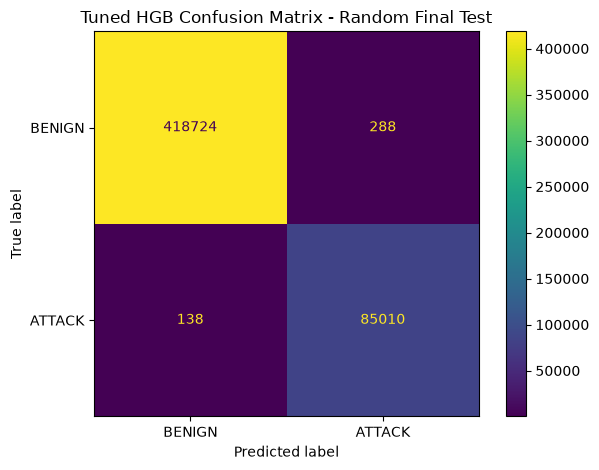

array([[418724,    288],
       [   138,  85010]])

In [26]:
# Save confusion matrix for random final test HGB

cm_hgb_final = confusion_matrix(
    y_test_final,
    hgb_test_preds,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hgb_final,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Tuned HGB Confusion Matrix - Random Final Test")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hgb_random_final_test_confusion_matrix.png", dpi=300)
plt.show()

cm_hgb_final

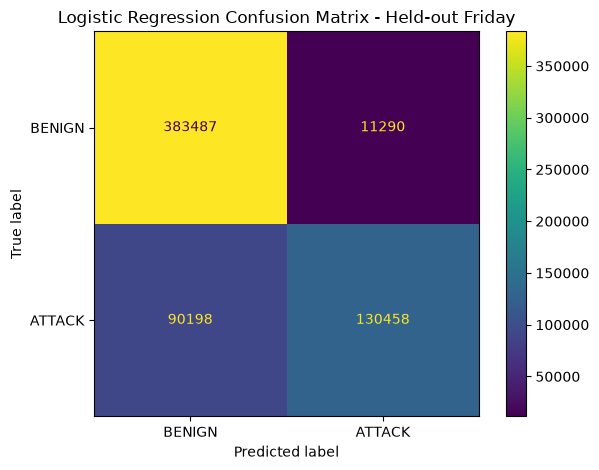

array([[383487,  11290],
       [ 90198, 130458]])

In [27]:
# Save confusion matrix for held-out Friday Logistic Regression

heldout_logreg_best_preds = np.where(
    heldout_logreg_scores >= 0.51,
    "ATTACK",
    "BENIGN"
)

cm_logreg_heldout = confusion_matrix(
    y_test_day,
    heldout_logreg_best_preds,
    labels=["BENIGN", "ATTACK"]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logreg_heldout,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot(values_format="d")
plt.title("Logistic Regression Confusion Matrix - Held-out Friday")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "logreg_heldout_friday_confusion_matrix.png", dpi=300)
plt.show()

cm_logreg_heldout

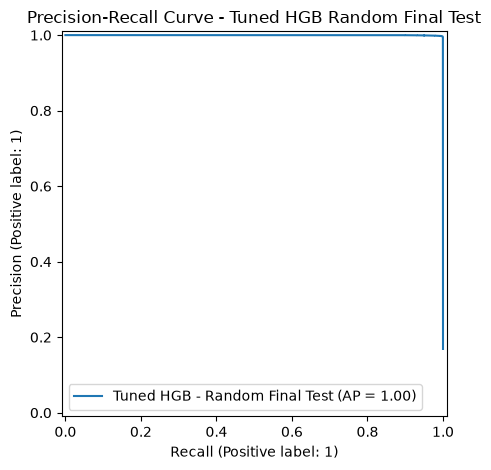

In [28]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    (y_test_final == "ATTACK").astype(int),
    hgb_test_scores,
    name="Tuned HGB - Random Final Test"
)

plt.title("Precision-Recall Curve - Tuned HGB Random Final Test")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "hgb_random_final_test_pr_curve.png", dpi=300)
plt.show()

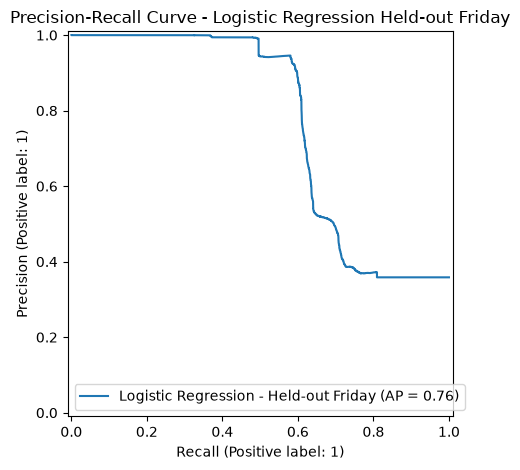

In [29]:
PrecisionRecallDisplay.from_predictions(
    (y_test_day == "ATTACK").astype(int),
    heldout_logreg_scores,
    name="Logistic Regression - Held-out Friday"
)

plt.title("Precision-Recall Curve - Logistic Regression Held-out Friday")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "logreg_heldout_friday_pr_curve.png", dpi=300)
plt.show()

In [30]:
# Save final models

joblib.dump(
    best_hgb_model,
    MODEL_DIR / "tuned_histgradientboosting_final_model.joblib"
)

joblib.dump(
    best_rf_model,
    MODEL_DIR / "tuned_random_forest_final_model.joblib"
)

joblib.dump(
    heldout_logreg_model,
    MODEL_DIR / "logistic_regression_heldout_friday_model.joblib"
)

print("Models saved:")
print(MODEL_DIR / "tuned_histgradientboosting_final_model.joblib")
print(MODEL_DIR / "tuned_random_forest_final_model.joblib")
print(MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

Models saved:
../models/tuned_histgradientboosting_final_model.joblib
../models/tuned_random_forest_final_model.joblib
../models/logistic_regression_heldout_friday_model.joblib


In [31]:
# Reload HGB and verify it reproduces the final random test result

loaded_hgb_model = joblib.load(
    MODEL_DIR / "tuned_histgradientboosting_final_model.joblib"
)

loaded_hgb_scores = get_attack_scores(loaded_hgb_model, X_test_final)

loaded_hgb_preds = np.where(
    loaded_hgb_scores >= best_hgb_threshold,
    "ATTACK",
    "BENIGN"
)

loaded_hgb_results = evaluate_predictions(
    y_test_final,
    loaded_hgb_preds,
    y_score=loaded_hgb_scores,
    dataset_name="Loaded HGB - Random Final Test"
)

assert abs(loaded_hgb_results["attack_f1"] - final_hgb_test_results["attack_f1"]) < 1e-6

print("Loaded HGB reproduces the saved final test result.")

Loaded HGB - Random Final Test
------------------------------------------------------------
accuracy: 0.9992
macro_precision: 0.9981
macro_recall: 0.9988
macro_f1: 0.9985
weighted_f1: 0.9992
attack_precision: 0.9966
attack_recall: 0.9984
attack_f1: 0.9975
pr_auc: 0.9999
roc_auc: 1.0000

Classification report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

Loaded HGB reproduces the saved final test result.


In [32]:
# Save final models

joblib.dump(
    best_hgb_model,
    MODEL_DIR / "tuned_histgradientboosting_final_model.joblib"
)

joblib.dump(
    best_rf_model,
    MODEL_DIR / "tuned_random_forest_final_model.joblib"
)

joblib.dump(
    heldout_logreg_model,
    MODEL_DIR / "logistic_regression_heldout_friday_model.joblib"
)

print("Models saved:")
print(MODEL_DIR / "tuned_histgradientboosting_final_model.joblib")
print(MODEL_DIR / "tuned_random_forest_final_model.joblib")
print(MODEL_DIR / "logistic_regression_heldout_friday_model.joblib")

Models saved:
../models/tuned_histgradientboosting_final_model.joblib
../models/tuned_random_forest_final_model.joblib
../models/logistic_regression_heldout_friday_model.joblib


In [33]:
# Reload HGB and verify it reproduces the final random test result

loaded_hgb_model = joblib.load(
    MODEL_DIR / "tuned_histgradientboosting_final_model.joblib"
)

loaded_hgb_scores = get_attack_scores(loaded_hgb_model, X_test_final)

loaded_hgb_preds = np.where(
    loaded_hgb_scores >= best_hgb_threshold,
    "ATTACK",
    "BENIGN"
)

loaded_hgb_results = evaluate_predictions(
    y_test_final,
    loaded_hgb_preds,
    y_score=loaded_hgb_scores,
    dataset_name="Loaded HGB - Random Final Test"
)

assert abs(loaded_hgb_results["attack_f1"] - final_hgb_test_results["attack_f1"]) < 1e-6

print("Loaded HGB reproduces the saved final test result.")

Loaded HGB - Random Final Test
------------------------------------------------------------
accuracy: 0.9992
macro_precision: 0.9981
macro_recall: 0.9988
macro_f1: 0.9985
weighted_f1: 0.9992
attack_precision: 0.9966
attack_recall: 0.9984
attack_f1: 0.9975
pr_auc: 0.9999
roc_auc: 1.0000

Classification report:
              precision    recall  f1-score   support

      ATTACK       1.00      1.00      1.00     85148
      BENIGN       1.00      1.00      1.00    419012

    accuracy                           1.00    504160
   macro avg       1.00      1.00      1.00    504160
weighted avg       1.00      1.00      1.00    504160

Loaded HGB reproduces the saved final test result.


In [34]:
# Reload held-out Logistic Regression and verify it reproduces the held-out Friday result

loaded_logreg_model = joblib.load(
    MODEL_DIR / "logistic_regression_heldout_friday_model.joblib"
)

loaded_logreg_scores = get_attack_scores(loaded_logreg_model, X_test_day)

loaded_logreg_preds = np.where(
    loaded_logreg_scores >= 0.51,
    "ATTACK",
    "BENIGN"
)

loaded_logreg_results = evaluate_predictions(
    y_test_day,
    loaded_logreg_preds,
    y_score=loaded_logreg_scores,
    dataset_name="Loaded Logistic Regression - Held-out Friday"
)

assert abs(loaded_logreg_results["attack_f1"] - best_heldout_threshold_row["attack_f1"]) < 1e-6

print("Loaded Logistic Regression reproduces the held-out Friday result.")

Loaded Logistic Regression - Held-out Friday
------------------------------------------------------------
accuracy: 0.8351
macro_precision: 0.8650
macro_recall: 0.7813
macro_f1: 0.8015
weighted_f1: 0.8246
attack_precision: 0.9204
attack_recall: 0.5912
attack_f1: 0.7200
pr_auc: 0.7632
roc_auc: 0.7292

Classification report:
              precision    recall  f1-score   support

      ATTACK       0.92      0.59      0.72    220656
      BENIGN       0.81      0.97      0.88    394777

    accuracy                           0.84    615433
   macro avg       0.86      0.78      0.80    615433
weighted avg       0.85      0.84      0.82    615433

Loaded Logistic Regression reproduces the held-out Friday result.


In [35]:
# Random Forest feature importance for artefact analysis

rf_classifier = best_rf_model.named_steps["classifier"]

feature_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_classifier.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance_df.to_csv(
    RESULTS_DIR / "random_forest_feature_importance_clean.csv",
    index=False
)

feature_importance_df.head(25)

,feature,importance
39,Max Packet Length,0.081599
41,Packet Length Std,0.073190
42,Packet Length Variance,0.064558
52,Average Packet Size,0.060506
54,Avg Bwd Segment Size,0.056952
10,Bwd Packet Length Max,0.044600
13,Bwd Packet Length Std,0.038708
0,Destination Port,0.035196
5,Total Length of Bwd Packets,0.031697
6,Fwd Packet Length Max,0.028224


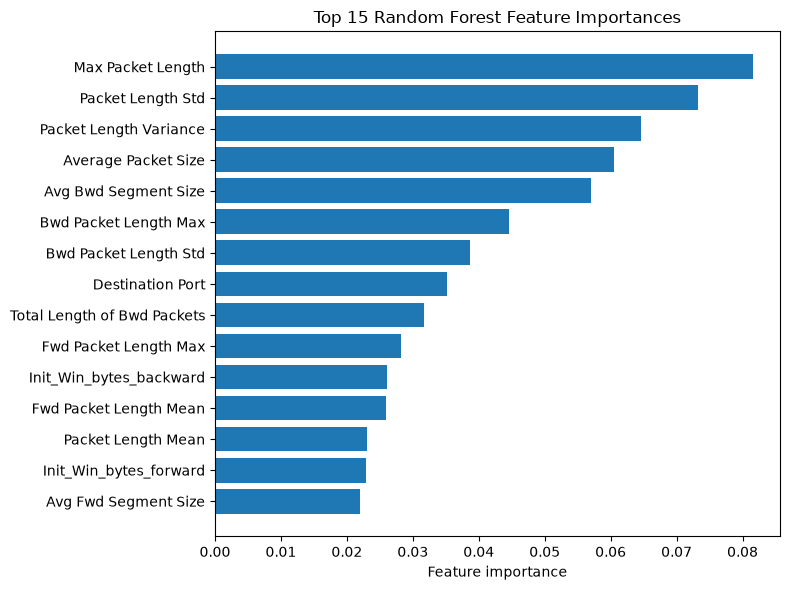

In [36]:
# Plot top 15 RF feature importances

top_features = feature_importance_df.head(15).sort_values(by="importance")

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.xlabel("Feature importance")
plt.title("Top 15 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "random_forest_top15_feature_importance.png", dpi=300)
plt.show()

In [37]:
print("Result files:")
for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

print("\nFigure files:")
for file in sorted(FIGURE_DIR.iterdir()):
    print(file.name)

print("\nModel files:")
for file in sorted(MODEL_DIR.iterdir()):
    print(file.name)

Result files:
attack_type_distribution.csv
best_heldout_friday_threshold_result.csv
final_test_results_clean.csv
heldout_friday_best_threshold_results.csv
heldout_friday_robustness_results_clean.csv
heldout_friday_threshold_sensitivity_results.csv
random_forest_feature_importance.csv
random_forest_feature_importance_clean.csv
random_split_model_comparison_results.csv
random_vs_heldout_summary_comparison.csv
source_file_binary_label_distribution.csv
tuned_validation_results_clean.csv
validation_model_comparison_clean.csv
validation_threshold_tuning_clean.csv

Figure files:
hgb_random_final_test_confusion_matrix.png
hgb_random_final_test_pr_curve.png
logistic_regression_heldout_friday_confusion_matrix.png
logreg_heldout_friday_confusion_matrix.png
logreg_heldout_friday_pr_curve.png
random_forest_random_split_confusion_matrix.png
random_forest_top15_feature_importance.png
random_forest_top_feature_importance.png

Model files:
logistic_regression_heldout_friday_model.joblib
random_forest_r

In [38]:
ARCHIVE_DIR = PROJECT_DIR / "outputs" / "archive_old_outputs"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

legacy_files = [
    RESULTS_DIR / "heldout_friday_best_threshold_results.csv",
    RESULTS_DIR / "random_forest_feature_importance.csv",
    RESULTS_DIR / "random_split_model_comparison_results.csv",
    FIGURE_DIR / "random_forest_random_split_confusion_matrix.png",
    FIGURE_DIR / "random_forest_top_feature_importance.png",
    MODEL_DIR / "random_forest_random_split_model.joblib",
]

for file in legacy_files:
    if file.exists():
        new_path = ARCHIVE_DIR / file.name
        file.rename(new_path)
        print(f"Moved {file.name} -> {new_path}")
    else:
        print(f"Not found, skipped: {file.name}")

Moved heldout_friday_best_threshold_results.csv -> ../outputs/archive_old_outputs/heldout_friday_best_threshold_results.csv
Moved random_forest_feature_importance.csv -> ../outputs/archive_old_outputs/random_forest_feature_importance.csv
Moved random_split_model_comparison_results.csv -> ../outputs/archive_old_outputs/random_split_model_comparison_results.csv
Moved random_forest_random_split_confusion_matrix.png -> ../outputs/archive_old_outputs/random_forest_random_split_confusion_matrix.png
Moved random_forest_top_feature_importance.png -> ../outputs/archive_old_outputs/random_forest_top_feature_importance.png
Moved random_forest_random_split_model.joblib -> ../outputs/archive_old_outputs/random_forest_random_split_model.joblib


In [39]:
print("Result files:")
for file in sorted(RESULTS_DIR.iterdir()):
    print(file.name)

print("\nFigure files:")
for file in sorted(FIGURE_DIR.iterdir()):
    print(file.name)

print("\nModel files:")
for file in sorted(MODEL_DIR.iterdir()):
    print(file.name)

print("\nArchived old outputs:")
for file in sorted(ARCHIVE_DIR.iterdir()):
    print(file.name)

Result files:
attack_type_distribution.csv
best_heldout_friday_threshold_result.csv
final_test_results_clean.csv
heldout_friday_robustness_results_clean.csv
heldout_friday_threshold_sensitivity_results.csv
random_forest_feature_importance_clean.csv
random_vs_heldout_summary_comparison.csv
source_file_binary_label_distribution.csv
tuned_validation_results_clean.csv
validation_model_comparison_clean.csv
validation_threshold_tuning_clean.csv

Figure files:
hgb_random_final_test_confusion_matrix.png
hgb_random_final_test_pr_curve.png
logistic_regression_heldout_friday_confusion_matrix.png
logreg_heldout_friday_confusion_matrix.png
logreg_heldout_friday_pr_curve.png
random_forest_top15_feature_importance.png

Model files:
logistic_regression_heldout_friday_model.joblib
tuned_histgradientboosting_final_model.joblib
tuned_random_forest_final_model.joblib

Archived old outputs:
heldout_friday_best_threshold_results.csv
random_forest_feature_importance.csv
random_forest_random_split_confusion_m

In [40]:
duplicate_figure = FIGURE_DIR / "logistic_regression_heldout_friday_confusion_matrix.png"

if duplicate_figure.exists():
    duplicate_figure.rename(ARCHIVE_DIR / duplicate_figure.name)
    print("Moved duplicate figure to archive.")
else:
    print("Duplicate figure not found.")

Moved duplicate figure to archive.
